# BDGDM single group

This notebook demonstrates detailed analysis and interpretation of one gene in one tumour subtype.
The example uses tumour samples only, no matched normal samples are required.

## Input data

BDGDM expects one row per sample and gene, with the following variables:

| Column | Description |
|---|---|
| `gene` | Gene identifier |
| `sampleID` | Unique tumour-sample identifier |
| `expr` | Raw RNA-seq count |
| `copies` | Absolute copy number |
| `subtype` | Biological group label; use one unique label for single-group analysis |
| `purity` | Tumour purity between 0 and 1 |
| `sf` | RNA-seq library-size factor |

One unique label invokes the *single-group model*, whereas two or more labels invoke the *subtype-comparison model*.

In [3]:
import platform
from importlib.resources import files

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cmdstanpy
from cmdstanpy import CmdStanModel

import bdgdm
from bdgdm import  BDGDMConfig, load_example_data, fit_one_gene_bdgdm, plot_classification 
from bdgdm.preprocessing import prepare_gene_data
from bdgdm.posterior import  get_posterior_summary_single
from bdgdm.diagnostics import  get_nuts_diagnostics

from bdgdm.plot_fit import plot_ppc_density
from bdgdm.classify import ClassificationThresholds, classify_fit, get_subtype_classification,  get_transition_classification, get_transition_df

import arviz as az
import xarray as xr

In [5]:
print("BDGDM version:", bdgdm.__version__)
print("Python version:", platform.python_version())
print("CmdStanPy:", cmdstanpy.__version__)
print("CmdStan:", cmdstanpy.cmdstan_path())

BDGDM version: 0.1.0
Python version: 3.11.7
CmdStanPy: 1.3.0
CmdStan: /Users/katsiarynadavydzenka/.cmdstan/cmdstan-2.34.1


## Load the example dataset

The example dataset is distributed with BDGDM so that the tutorial can be executed without downloading external data.

In [8]:
data = load_example_data()

print("Rows:", len(data))
print("Genes:", data["gene"].nunique())
print("Samples:", data["sampleID"].nunique())

data.head()

Rows: 104516
Genes: 106
Samples: 986


,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,ACVR1B,CRC.SW.U0001.T,7593,2,MSS,0.41,3.8,1.293201
1,ACVR1B,CRC.SW.U0002.T,5003,2,MSS,0.37,3.3,1.024008
2,ACVR1B,CRC.SW.U0004.T,4994,2,MSS,0.58,3.2,1.169870
3,ACVR1B,CRC.SW.U0030.T,6231,2,MSS,0.59,2.2,1.290047
4,ACVR1B,CRC.SW.U0066.T,2908,2,MSS,0.41,1.9,0.971163


## Select one gene and one tumour subtype

We use a single gene and a single subtype so that BDGDM selects the single-group model.
A gene should have:
- reasonable expression;
- enough tumour samples;
- enough copy-number-altered samples

### Calculate CN variability within the selected subtype to select representative gene.

In [12]:
subtype = "MSS"

cn_variability = (
    data.loc[data["subtype"].eq(subtype)]
    .groupby("gene", as_index=False)
    .agg(
        cn_sd=("copies", "std"),
        cn_variance=("copies", "var"),
        cn_range=("copies", lambda x: x.max() - x.min()),
        n_cn_states=("copies", "nunique"),
        n_samples=("sampleID", "nunique"),
        mean_expr=("expr", "mean"),
    )
    .sort_values(
        ["cn_sd", "n_cn_states"],
        ascending=[False, False],
    )
)

cn_variability.head(10)

,gene,cn_sd,cn_variance,cn_range,n_cn_states,n_samples,mean_expr
41,ERBB2,0.949797,0.902113,7,6,778,10473.332905
86,SLC46A3,0.881115,0.776365,6,7,778,1201.821337
11,ASXL1,0.807710,0.652396,6,7,778,4839.376607
33,CSF3,0.760403,0.578213,7,7,778,102.273779
48,GNAS,0.716607,0.513525,4,5,778,24628.548843
84,SKA3,0.692006,0.478872,5,6,778,1024.164524
53,KLF5,0.684916,0.469110,6,6,778,17886.439589
87,SMAD2,0.573987,0.329461,7,5,778,4441.992288
72,RBM10,0.525175,0.275809,7,6,778,2151.092545
89,SMAD4,0.524456,0.275054,3,4,778,1971.068123


In [14]:
# Select a gene as example

gene = "ASXL1"
subtype = "MSS"

gene_df = (
    data.loc[
        data["gene"].eq(gene)
        & data["subtype"].eq(subtype)
    ]
    .copy()
    .reset_index(drop=True)
)

print("Gene:", gene)
print("Subtype:", subtype)
print("Samples:", len(gene_df))
print("Observed CN states:", sorted(gene_df["copies"].unique()))

gene_df.head()

Gene: ASXL1
Subtype: MSS
Samples: 778
Observed CN states: [2, 3, 4, 5, 6, 7, 8]


,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,ASXL1,CRC.SW.U0001.T,9578,4,MSS,0.41,3.8,1.293201
1,ASXL1,CRC.SW.U0002.T,6899,3,MSS,0.37,3.3,1.024008
2,ASXL1,CRC.SW.U0004.T,7049,4,MSS,0.58,3.2,1.169870
3,ASXL1,CRC.SW.U0030.T,5707,3,MSS,0.59,2.2,1.290047
4,ASXL1,CRC.SW.U0066.T,5014,2,MSS,0.41,1.9,0.971163


### Check CN-state coverage

BDGDM estimates the CN response from variation across tumour samples. A gene observed almost exclusively at CN = 2 contains little
information about dosage sensitivity.

The number of samples in each copy-number state should therefore be examined before model fitting. Rare states may produce broad posterior intervals even when the fitted effect is large.

In [17]:
cn_summary = (
    gene_df.groupby("copies", as_index=False)
    .agg(
        n_samples=("sampleID", "nunique"),
        mean_count=("expr", "mean"),
        median_count=("expr", "median"),
        mean_purity=("purity", "mean"),
    )
)
cn_summary

,copies,n_samples,mean_count,median_count,mean_purity
0,2,300,3506.213333,3479.0,0.464567
1,3,364,5077.846154,4954.0,0.497912
2,4,89,7161.629213,7151.0,0.539888
3,5,20,8898.150000,8858.5,0.619000
4,6,3,8065.333333,9064.0,0.656667
5,7,1,12329.000000,12329.0,0.620000
6,8,1,12962.000000,12962.0,0.400000


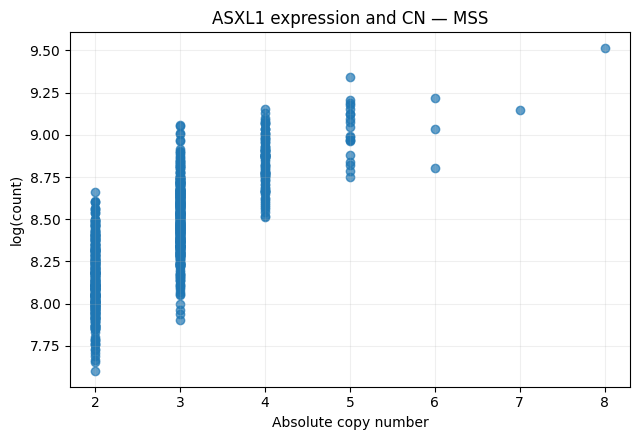

In [19]:
# Simple observed-data plot

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.scatter(
    gene_df["copies"],
    np.log1p(gene_df["expr"] / gene_df["sf"]),
    alpha=0.7,
)

ax.set_xlabel("Absolute copy number")
ax.set_ylabel("log(count)")
ax.set_title(f"{gene} expression and CN — {subtype}")
ax.grid(alpha=0.2)

fig.tight_layout()

*ASXL1* contains diploid and gain/amplification states but no observed CN=1 samples in the selected MSS cohort. This example is therefore interpreted as a gain/amplification-focused analysis. 

## Fit BDGDM

Because the selected data contain one subtype, BDGDM uses the single-group model.

We use NUTS sampling to obtain posterior estimates. Variational inference can be used for rapid exploratory analyses, but NUTS is recommended
when accurate posterior uncertainty is required.

In [23]:
# Configure the fit
config = BDGDMConfig(
    engine="nuts",
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.90,
    max_treedepth=12,
    return_ppc=True,
    save_draws=False,
    save_summary=False,
    seed=123
)

In [25]:
# Run BDGDM

stan_dir = files("bdgdm").joinpath("stan")

model_single = CmdStanModel(
    stan_file=str(
        stan_dir.joinpath("bdgdm_single.stan")
    )
)

model_subtype = CmdStanModel(
    stan_file=str(
        stan_dir.joinpath("bdgdm_subtype.stan")
    )
)

fit = fit_one_gene_bdgdm(
    gene_df=gene_df,
    gene="ASXL1",
    model_single=model_single,
    model_subtype=model_subtype,
    cna="amp",
    config=config
)

11:03:20 - cmdstanpy - INFO - CmdStan start processing
11:03:20 - cmdstanpy - INFO - Chain [1] start processing
11:03:20 - cmdstanpy - INFO - Chain [2] start processing
11:03:20 - cmdstanpy - INFO - Chain [3] start processing
11:03:20 - cmdstanpy - INFO - Chain [4] start processing
11:03:41 - cmdstanpy - INFO - Chain [4] done processing
11:03:42 - cmdstanpy - INFO - Chain [2] done processing
11:03:44 - cmdstanpy - INFO - Chain [3] done processing
11:03:45 - cmdstanpy - INFO - Chain [1] done processing


## Posterior parameter estimates

The main BDGDM parameters are:

| Parameter | Interpretation |
|---|---|
| `b0` | Log tumour-component expression baseline at diploid CN (CN=2). |
| `b_scaling` | Coefficient multiplying `log(CN/2)`; `b_scaling = 1` represents proportional scaling when `b_deviation = 0`. |
| `b_deviation` | Additional response multiplying `(CN−2)/2`; it can attenuate or reinforce the scaling component. |
| `b_noncancer_log` | Log expression baseline of the non-cancer component. |
| `phi` | Negative-binomial dispersion. |

For sample n, the tumour linear predictor is:

$
\eta_n =
\beta_0 +
\beta_{\mathrm{scaling}}\log(CN_n/2) +
\beta_{\mathrm{deviation}}(CN_n-2)/2
$

The expected total count combines tumour and non-cancer components:

$
\mu_n =
sf_n\left[
p_n e^{\eta_n}
+
(1-p_n)e^{b_{\mathrm{non-cancer}}}
\right]
$

where $p_n$ is tumour purity.

Posterior medians should always be interpreted together with their credible intervals.

In [28]:
posterior_summary = fit.posterior
metadata_df, parameter_summary, transition_summary = (
    get_posterior_summary_single(
        posterior_summary
    )
)

display(metadata_df)
display(parameter_summary.round(3))
display(transition_summary.round(3))

,analysis_mode,engine,n_subtypes,subtype
0,single_group,nuts,1,MSS


,parameter,subtype,median,q025,q975
0,b0,MSS,7.946,7.876,8.014
1,b_scaling,MSS,1.935,1.540,2.302
2,b_deviation,MSS,-0.228,-0.460,0.018
3,b_noncancer_log,None,8.376,8.330,8.419
4,phi,None,23.730,21.463,26.214


,transition,subtype,lp_median,lp_q025,lp_q975,fractional_change_median,fractional_change_q025,fractional_change_q975,p_positive,p_negative,p_rope,ppd,scaling_component_median,deviation_component_median,cancellation_index_median
0,2→1,MSS,-1.225,-1.376,-1.067,-0.706,-0.748,-0.656,0.0,1.0,0.0,1.0,-1.341,0.114,0.085
1,2→3,MSS,0.670,0.617,0.723,0.954,0.853,1.060,1.0,0.0,0.0,1.0,0.784,-0.114,-0.145
2,2→4,MSS,1.112,1.038,1.188,2.040,1.822,2.282,1.0,0.0,0.0,1.0,1.341,-0.228,-0.170


The posterior for `b_scaling` is substantially above 1, with a median of approximately 1.94 and a 95% CI of 1.54–2.30. This supports a
scaling component stronger than the canonical proportional response.

The posterior median of `b_deviation` is negative, indicating attenuation of the scaling component. However, its 95% CI, −0.46 to 0.02, slightly overlaps zero, so strong evidence for a non-zero deviation is absent.

The net transition effects combine both components and should therefore be used for final response classification.

## Model diagnostics

Posterior estimates should be interpreted only after checking sampling quality. 
We inspect split $\widehat{R}$, ESS, divergent transitions, and the overall CmdStan diagnostic status.

In [32]:
diagnostics = fit.diagnostics

diagnostic_checks = get_nuts_diagnostics(
    diagnostics
)

diagnostic_checks

,check,value,passed
0,Overall diagnostic status,ok,True
1,Convergence flag,True,True
2,Maximum core R-hat,1.00168,True
3,Minimum core bulk ESS,1597.22,True
4,Divergent transitions,0,True


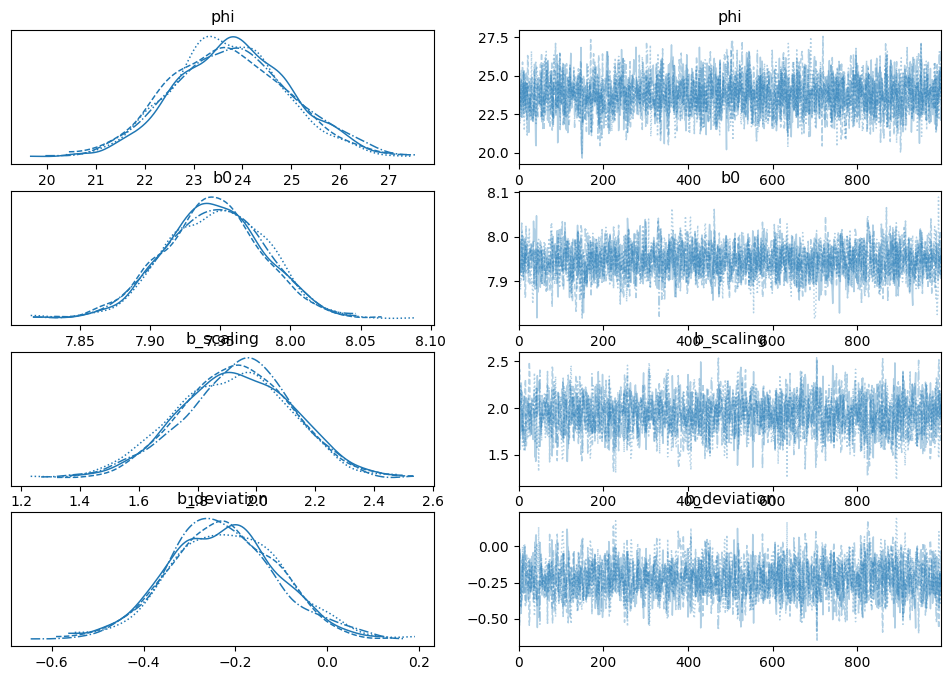

In [34]:
# Trace plots
idata = az.from_cmdstanpy(posterior=fit.fit)
available = list(idata.posterior.data_vars)

az.plot_trace(
    idata,
    var_names=[
        "phi",
        "b0",
        "b_scaling",
        "b_deviation",
    ],
)

plt.show()

## Posterior predictive check

Posterior predictive checks (PPCs) compare the observed counts with counts generated from the fitted model.

Good agreement does not prove that the biological model is correct, but systematic discrepancies can reveal inadequate fit, unmodelled heterogeneity, or poorly represented copy-number states.

In [37]:
processed, stan_data, metadata = prepare_gene_data(
    gene_df=gene_df,
    gene="ASXL1",
    cna="amp",
    et=0.15,
    min_aneup=5,
    min_unique_counts=5,
    min_cn_abs_sum=1.0,
)

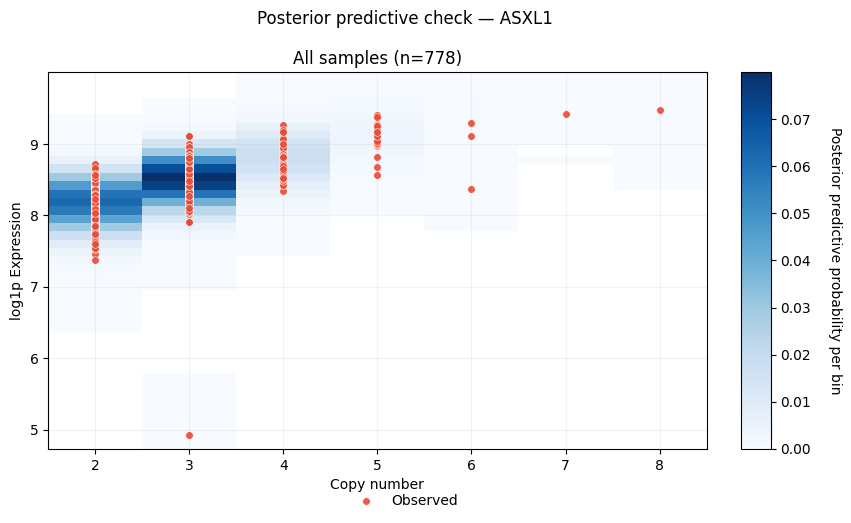

In [39]:
fig, axes, ppc_summary = plot_ppc_density(
    fit,
    x_observed=processed["copies"],
    y_observed=stan_data["y"],
    subtype_observed=None,
    subtype_order=None,
    gene="ASXL1",
    transform="log1p",
    x_bins="integer",
    density_mode="probability",
    figsize=(8.5, 5.7),
)

The posterior predictive distribution reproduced the overall increase in ASXL1 expression with increasing CN and covered most observed values at the well-represented CN states. 
One strong low-expression outlier is observed at CN=3. 
Predictions at CN = 5 - CN = 8 are less informative because these CN states contained relatively few samples.

## Classify the gene-dosage response

The fitted posterior is continuous, whereas the final response class is a discrete summary. 
Classification combines posterior transition effects, directional probabilities, ROPE probabilities, and credible-interval support using predefined thresholds.

Possible outputs include:

- **DSG**: proportional CN–expression response;
- **DCG**: an attenuated response relative to proportional dosage scaling;
- **HYPER**: a response stronger than the proportional expectation;
- **Mixed**: different response patterns supported by different CN transitions;
- **UNC**: the posterior is valid, but the evidence is insufficient for a specific response class;
- **DIG**: little or no supported expression response to CN change.

In [43]:
# Define classification thresholds
thresholds = ClassificationThresholds(
    ppd_sig=0.95,
    rope_low=0.05,
    rope_high=0.95,
    dose_prob_sensitive=0.95,
    dose_prob_insensitive=0.95,
    cancel_threshold=0.20,
    overcomp_threshold=1.00,
    hyper_threshold=0.50,
    low_cn_aneup_threshold=5,
)

In [45]:
# Classify
classif = classify_fit(fit,
                      thresholds=thresholds)

subtype_result = get_subtype_classification(classif,
                                            subtype="MSS")
subtype_result

{'gene': 'ASXL1',
 'status': 'ok',
 'fit_flag': 'ok',
 'analysis_mode': 'single_group',
 'N': 778,
 'n_aneup': 478,
 'cna': 'amp',
 'subtype_index': 1,
 'subtype': 'MSS',
 'response_class': 'Mixed',
 'response_reason': 'conflicting_supported_transition_patterns',
 'response_subclass': None,
 'b_scaling_median': 1.9348,
 'b_deviation_median': -0.2276995,
 'p_deviation_small': 0.14275,
 'small_deviation': False,
 'small_deviation_method': 'posterior_probability',
 'dc_gain': False,
 'dc_loss': False,
 'dc_type': 'none'}

In [47]:
# Transition-level posterior evidence

transition_table = get_transition_df(classif)
transition_table

,gene,subtype_index,subtype,transition,transition_key,pattern,supported,null,support_method,fractional_change_median,direction_probability,rope_probability,ppd,response_ratio,hyper_supported,hyper_evidence_method,reverse_supported,cancellation_index
0,ASXL1,1,MSS,2→1,2to1,hyperactive,True,False,posterior_expected_direction,-0.706332,1.0,0.0,1.0,1.767741,True,credible_interval,False,0.085044
1,ASXL1,1,MSS,2→3,2to3,hyperactive,True,False,posterior_expected_direction,0.953748,1.0,0.0,1.0,1.651806,True,credible_interval,False,-0.145384
2,ASXL1,1,MSS,2→4,2to4,proportional,True,False,posterior_expected_direction,2.039704,1.0,0.0,1.0,1.603931,False,credible_interval,False,-0.170088


ASXL1 expression increases strongly with CN gain in MSS tumours. The scaling component is substantially stronger than proportional, while the deviation component provides modest attenuation.

The CN 2→3 transition is credibly hyperactive. The CN 2→4 transition has a median response above the HYPER boundary, but its uncertainty narrowly overlaps that boundary. Under the predefined classification rules, the supported gain transitions are therefore not completely uniform and the overall result is classified as `Mixed`.

Because no CN=1 samples are observed, the CN 2→1 estimate is an extrapolation and should not be treated as direct evidence for a loss response.

## Interpretation

The final class should not be interpreted in isolation.

The conclusion should combine:

1. CN-state coverage in the observed data;
2. posterior estimates and credible intervals;
3. convergence diagnostics;
4. PPCs;
5. transition-level posterior evidence;
6. the final response class.

For example, a `DCG` classification indicates that the expression response is weaker than the canonical/proportional dosage expectation. Additional regulatory, epigenetic, or functional analyses are needed to identify potential molecular mechanisms.

An `UNC` result is an abstention rather than a biological class. It indicates that the available samples do not provide sufficient posterior evidence for a confident assignment.

## Next steps

For joint estimation and comparison across tumour subtypes, continue to the [subtype-comparison vignette](subtype_comparison.ipynb).